# Análise Exploratória dos Dados de Marketing

Neste notebook, exploramos o dataset de Marketing Mix Modeling (MMM) com **104 semanas** de dados sintéticos que simulam o investimento em 5 canais de marketing e a receita resultante.
O objetivo é entender a estrutura dos dados, identificar padrões sazonais e relações entre variáveis antes de partir para a modelagem.

In [1]:
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

# Configurações visuais globais
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "Arial", "Helvetica", "DejaVu Sans"],
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})
sns.set_style("whitegrid")

# Paleta oficial do projeto
CORES = {
    "Meta Ads": "#1877F2",
    "Google Ads": "#34A853",
    "LinkedIn Ads": "#0A66C2",
    "Email Marketing": "#FF6B35",
    "Conteúdo Orgânico": "#7C3AED",
    "Baseline": "#94A3B8",
}

# Carregar dados
caminho_csv = os.path.join("..", "data", "raw", "marketing_data.csv")
df = pd.read_csv(caminho_csv, parse_dates=["date"])

print(f"Dataset carregado: {caminho_csv}")
print(f"Shape: {df.shape[0]} linhas × {df.shape[1]} colunas")

Dataset carregado: ..\data\raw\marketing_data.csv
Shape: 104 linhas × 17 colunas


## 1. Visão Geral do Dataset

Vamos inspecionar a estrutura, os tipos de dados e as estatísticas descritivas para entender o que temos em mãos.

In [2]:
# Dimensões e período
print(f"Dimensões: {df.shape[0]} semanas × {df.shape[1]} colunas")
print(f"Período: {df['date'].min().date()} a {df['date'].max().date()}")
print(f"Valores nulos: {df.isnull().sum().sum()}")
print()

# Tipos de dados
print("=" * 60)
print("TIPOS DE DADOS")
print("=" * 60)
df.info()
print()

# Estatísticas descritivas
print("=" * 60)
print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 60)
df.describe().round(2)

Dimensões: 104 semanas × 17 colunas
Período: 2024-01-01 a 2025-12-22
Valores nulos: 0

TIPOS DE DADOS
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   date                    104 non-null    datetime64[us]
 1   revenue                 104 non-null    float64       
 2   spend_meta_ads          104 non-null    float64       
 3   spend_google_ads        104 non-null    float64       
 4   spend_linkedin_ads      104 non-null    float64       
 5   spend_email_marketing   104 non-null    float64       
 6   spend_content_organic   104 non-null    float64       
 7   impressions_meta        104 non-null    int64         
 8   impressions_google      104 non-null    int64         
 9   clicks_meta             104 non-null    int64         
 10  clicks_google           104 non-null    int64         
 11  leads_total        

,date,revenue,spend_meta_ads,spend_google_ads,spend_linkedin_ads,spend_email_marketing,spend_content_organic,impressions_meta,impressions_google,clicks_meta,clicks_google,leads_total,conversions,is_holiday,is_black_friday,seasonality_index,competitor_spend_index
count,104,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00,104.00
mean,2024-12-26 12:00:00,139253.21,5295.78,3959.48,1986.15,1324.94,655.69,349611.71,158089.01,4190.76,5531.33,982.03,78.63,0.13,0.02,1.08,1.08
min,2024-01-01 00:00:00,116239.37,3580.80,2692.91,1379.55,883.55,468.35,231262.00,98280.00,2616.00,3002.00,558.00,39.00,0.00,0.00,0.95,0.88
25%,2024-06-29 06:00:00,129316.06,4664.36,3460.02,1742.61,1148.59,577.70,296359.00,140495.00,3531.00,4859.75,872.00,65.75,0.00,0.00,1.00,0.98
50%,2024-12-26 12:00:00,137211.84,5271.18,3924.98,1976.02,1336.66,649.51,345202.00,155130.50,4077.50,5441.00,974.00,78.00,0.00,0.00,1.05,1.06
75%,2025-06-24 18:00:00,145577.19,5784.52,4343.88,2163.79,1465.84,716.62,396297.00,173103.00,4746.75,6174.00,1090.00,88.00,0.00,0.00,1.15,1.16
max,2025-12-22 00:00:00,209902.72,8253.40,6276.90,2921.71,1901.72,945.19,599879.00,284165.00,7219.00,9391.00,1417.00,128.00,1.00,1.00,1.30,1.42
std,NaN,15491.46,888.53,643.02,305.04,219.70,96.59,71153.75,27811.75,897.18,1106.41,164.23,17.75,0.34,0.14,0.11,0.13


### Interpretação

O dataset cobre **2 anos completos** (104 semanas) sem valores nulos — está limpo e pronto para análise.
A receita semanal média gira em torno de **R$ 139 mil**, com investimento total médio de aproximadamente **R$ 14 mil/semana** distribuído entre 5 canais.
Meta Ads e Google Ads concentram a maior fatia do orçamento, enquanto Conteúdo Orgânico recebe a menor alocação — um padrão típico de operações de marketing digital no Brasil.

## 2. Receita ao Longo do Tempo

Vamos visualizar a série temporal de receita para identificar sazonalidade, tendência e possíveis outliers.

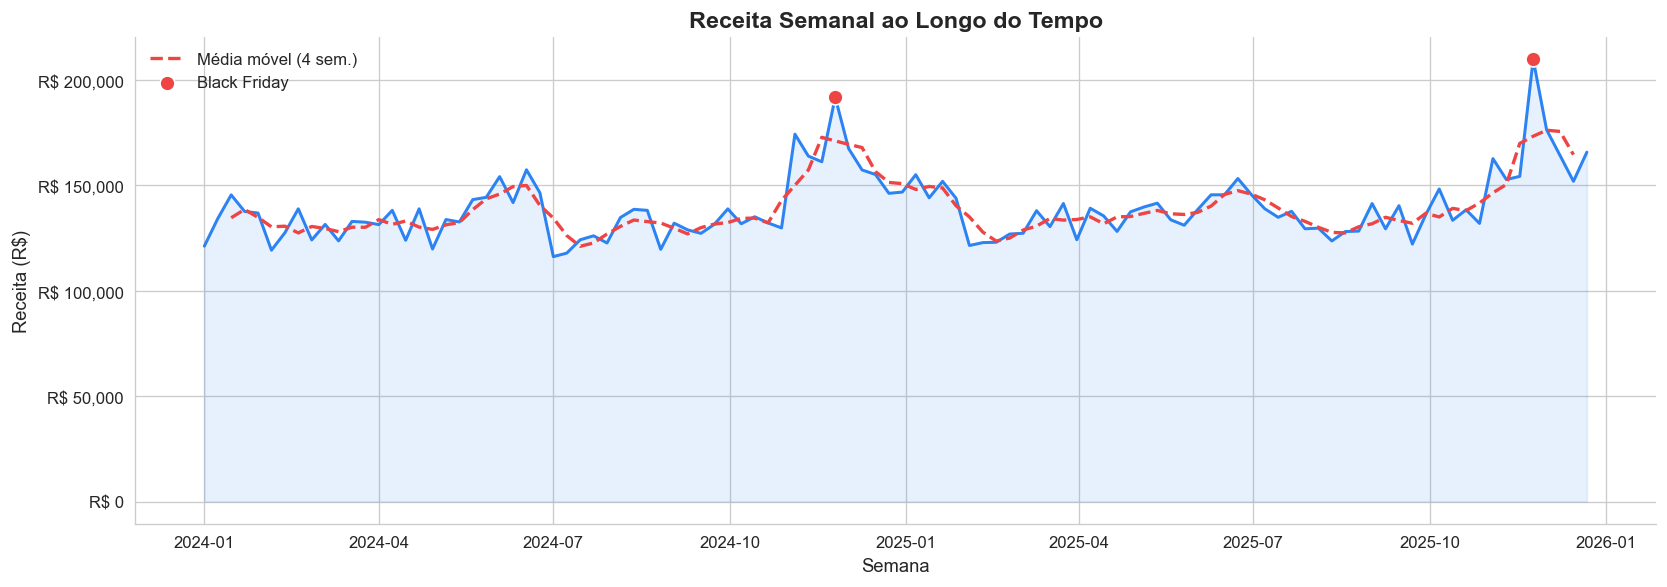

Receita média semanal:  R$   139,253.21
Receita mínima:         R$   116,239.37
Receita máxima:         R$   209,902.72
Desvio padrão:          R$    15,491.46
Coeficiente de variação:    11.1%


In [3]:
# Receita semanal ao longo do tempo
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df["date"], df["revenue"], color="#1877F2", linewidth=1.8, alpha=0.9)
ax.fill_between(df["date"], df["revenue"], alpha=0.1, color="#1877F2")

# Média móvel de 4 semanas para suavizar
media_movel = df["revenue"].rolling(window=4, center=True).mean()
ax.plot(df["date"], media_movel, color="#EF4444", linewidth=2, linestyle="--",
        label="Média móvel (4 sem.)")

# Destacar Black Friday
bf_mask = df["is_black_friday"] == 1
if bf_mask.any():
    ax.scatter(df.loc[bf_mask, "date"], df.loc[bf_mask, "revenue"],
               color="#EF4444", s=80, zorder=5, label="Black Friday", edgecolors="white")

ax.set_title("Receita Semanal ao Longo do Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Semana")
ax.set_ylabel("Receita (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Estatísticas resumidas
print(f"Receita média semanal:  R$ {df['revenue'].mean():>12,.2f}")
print(f"Receita mínima:         R$ {df['revenue'].min():>12,.2f}")
print(f"Receita máxima:         R$ {df['revenue'].max():>12,.2f}")
print(f"Desvio padrão:          R$ {df['revenue'].std():>12,.2f}")
print(f"Coeficiente de variação:    {df['revenue'].std() / df['revenue'].mean() * 100:.1f}%")

### Observações

A receita apresenta um **padrão sazonal claro**: picos em novembro/dezembro (Black Friday e Natal) e em junho (Dia dos Namorados), com vales em fevereiro e julho.
A média móvel de 4 semanas revela uma **leve tendência de crescimento** ao longo dos 2 anos, consistente com o amadurecimento da operação de marketing.
O coeficiente de variação moderado indica que, fora dos picos sazonais, a receita é relativamente estável — bom sinal para a modelagem.

## 3. Investimento por Canal ao Longo do Tempo

Como cada canal recebe investimento ao longo das semanas? Há variação na alocação ou ela é estável?

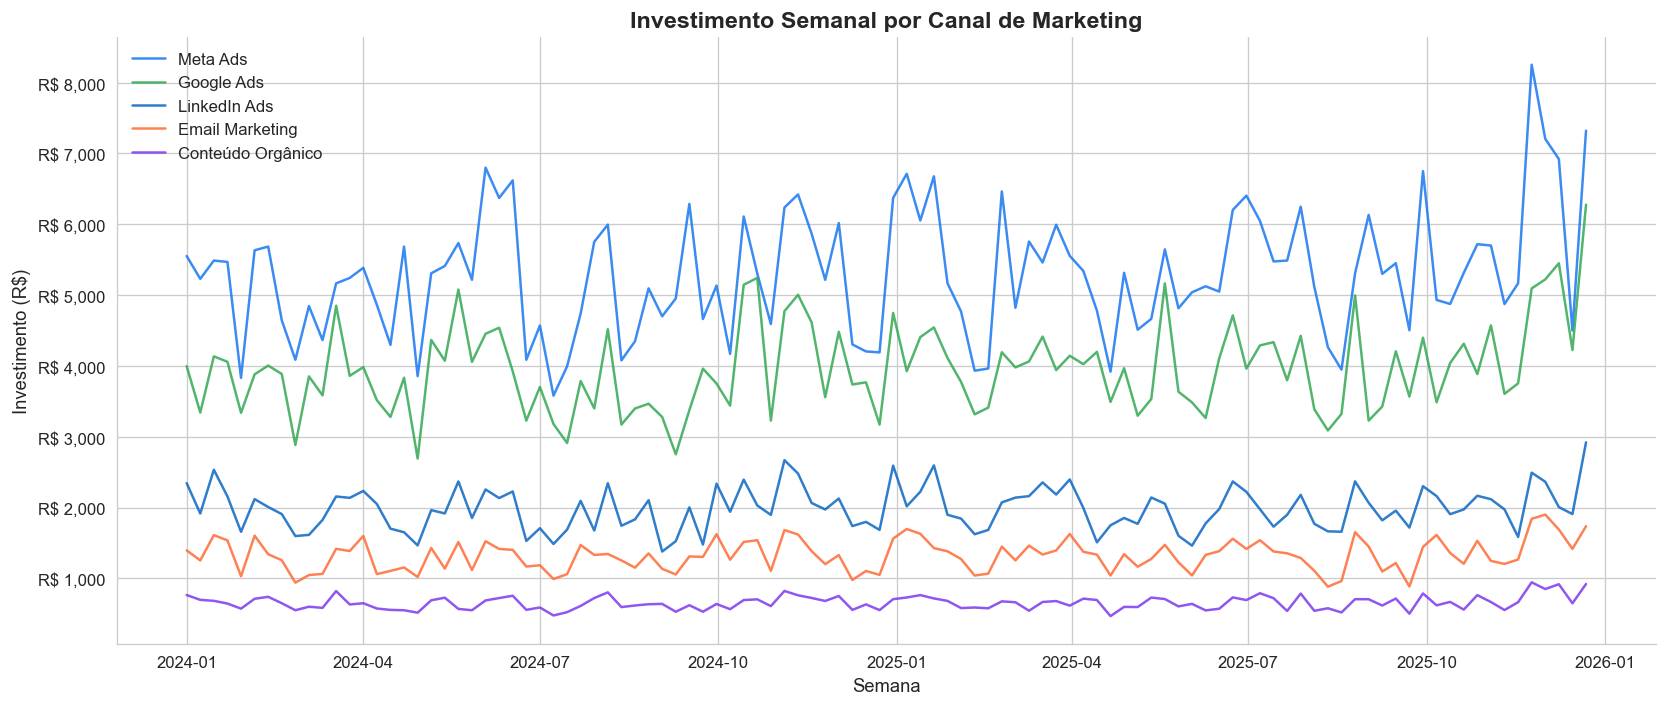

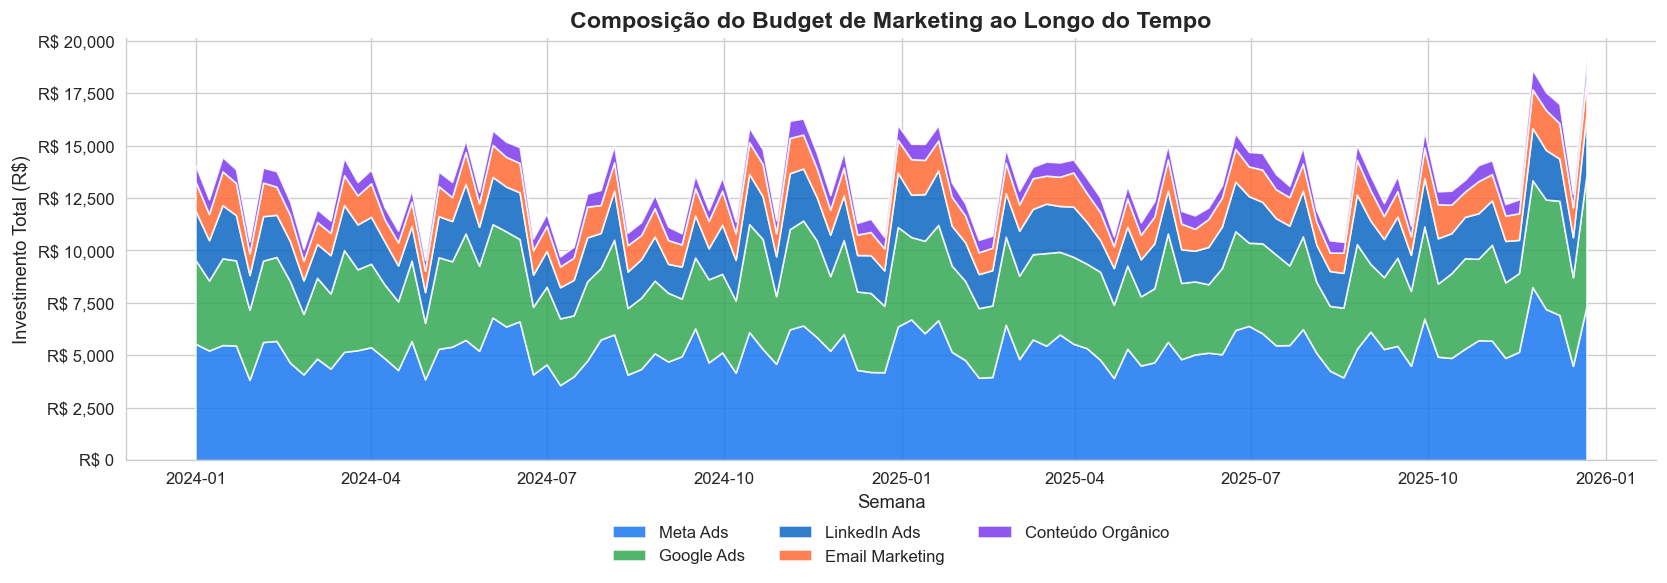

,Canal,Investimento Total (R$),Média Semanal (R$),% do Budget
0,Meta Ads,550760.99,5295.78,40.05
1,Google Ads,411786.42,3959.48,29.95
2,LinkedIn Ads,206559.32,1986.15,15.02
3,Email Marketing,137794.11,1324.94,10.02
4,Conteúdo Orgânico,68191.44,655.69,4.96


In [4]:
# Mapeamento de colunas de spend para nomes de exibição
colunas_spend = {
    "spend_meta_ads": "Meta Ads",
    "spend_google_ads": "Google Ads",
    "spend_linkedin_ads": "LinkedIn Ads",
    "spend_email_marketing": "Email Marketing",
    "spend_content_organic": "Conteúdo Orgânico",
}

# --- Gráfico de linhas: investimento por canal ---
fig, ax = plt.subplots(figsize=(14, 6))

for col, nome in colunas_spend.items():
    ax.plot(df["date"], df[col], label=nome, color=CORES[nome], linewidth=1.5, alpha=0.85)

ax.set_title("Investimento Semanal por Canal de Marketing", fontsize=14, fontweight="bold")
ax.set_xlabel("Semana")
ax.set_ylabel("Investimento (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(frameon=False, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# --- Gráfico de área empilhada: composição do budget ---
fig, ax = plt.subplots(figsize=(14, 5))

y_data = [df[col].values for col in colunas_spend.keys()]
labels = list(colunas_spend.values())
cores_lista = [CORES[nome] for nome in labels]

ax.stackplot(df["date"], y_data, labels=labels, colors=cores_lista, alpha=0.85)

ax.set_title("Composição do Budget de Marketing ao Longo do Tempo", fontsize=14, fontweight="bold")
ax.set_xlabel("Semana")
ax.set_ylabel("Investimento Total (R$)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"R$ {x:,.0f}"))
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

# Tabela resumo de investimento
resumo_spend = pd.DataFrame({
    "Canal": colunas_spend.values(),
    "Investimento Total (R$)": [df[col].sum() for col in colunas_spend],
    "Média Semanal (R$)": [df[col].mean() for col in colunas_spend],
    "% do Budget": [df[col].sum() / sum(df[c].sum() for c in colunas_spend) * 100
                    for col in colunas_spend],
}).round(2)
resumo_spend.sort_values("% do Budget", ascending=False, ignore_index=True)

### Padrões de Investimento

A alocação segue uma distribuição concentrada: **Meta Ads (~40%) e Google Ads (~30%)** dominam o orçamento, enquanto LinkedIn, Email e Conteúdo Orgânico dividem os 30% restantes.
Há uma leve tendência de crescimento no investimento total ao longo do tempo, acompanhando o aumento do budget mensal.
A variação semana a semana é natural — reflete ajustes operacionais e a sazonalidade (mais investimento em períodos de pico como Black Friday e Natal).

## 4. Matriz de Correlação

Quais variáveis estão mais relacionadas com a receita? Existe multicolinearidade entre os canais?

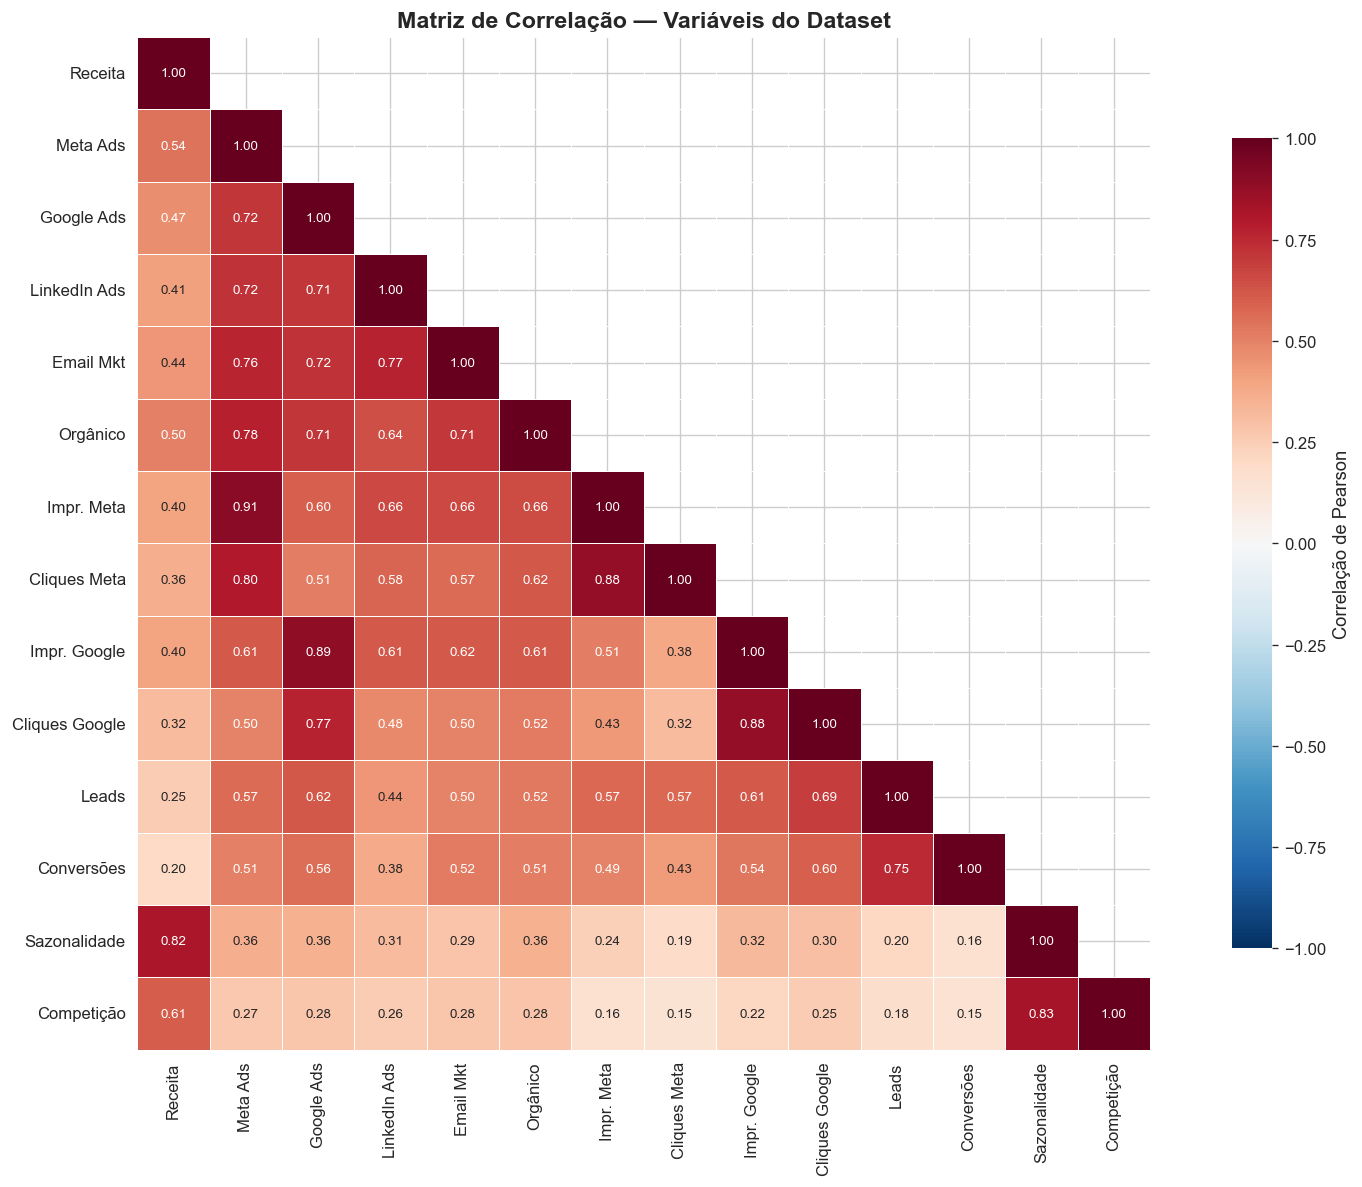

Correlação com a Receita (top 5):
  Sazonalidade         +0.815
  Competição           +0.608
  Meta Ads             +0.540
  Orgânico             +0.501
  Google Ads           +0.465


In [5]:
# Selecionar variáveis numéricas relevantes para a correlação
colunas_corr = [
    "revenue",
    "spend_meta_ads", "spend_google_ads", "spend_linkedin_ads",
    "spend_email_marketing", "spend_content_organic",
    "impressions_meta", "clicks_meta",
    "impressions_google", "clicks_google",
    "leads_total", "conversions",
    "seasonality_index", "competitor_spend_index",
]

nomes_curtos = [
    "Receita",
    "Meta Ads", "Google Ads", "LinkedIn Ads",
    "Email Mkt", "Orgânico",
    "Impr. Meta", "Cliques Meta",
    "Impr. Google", "Cliques Google",
    "Leads", "Conversões",
    "Sazonalidade", "Competição",
]

corr = df[colunas_corr].corr()
corr.index = nomes_curtos
corr.columns = nomes_curtos

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.5, square=True, ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Correlação de Pearson"},
    annot_kws={"size": 8},
)

ax.set_title("Matriz de Correlação — Variáveis do Dataset", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlações com receita
corr_receita = corr["Receita"].drop("Receita").sort_values(ascending=False)
print("Correlação com a Receita (top 5):")
for nome, valor in corr_receita.head(5).items():
    print(f"  {nome:<20s} {valor:+.3f}")

### Análise das Correlações

Pontos-chave da matriz de correlação:

- **Sazonalidade e competição** apresentam correlação elevada com a receita — o que faz sentido, já que tanto o mercado quanto a empresa investem mais nos mesmos períodos de pico.
- Os **canais de spend** têm correlação positiva com a receita, mas moderada. Isso é esperado: a relação entre investimento e receita não é linear simples (existe adstock e saturação).
- **Alta correlação entre canais** (ex.: Meta Ads e Google Ads) indica que o budget sobe e desce junto em todos os canais — um reflexo da alocação proporcional ao budget total. Isso gera multicolinearidade, que trataremos na modelagem com VIF.
- **Impressões e cliques** são altamente correlacionados com seus respectivos spends (óbvio: mais budget = mais impressões). Não os usaremos como features no modelo para evitar redundância.

## 5. Distribuição das Variáveis

Vamos inspecionar a distribuição de cada variável para identificar assimetrias, outliers e a forma geral dos dados.

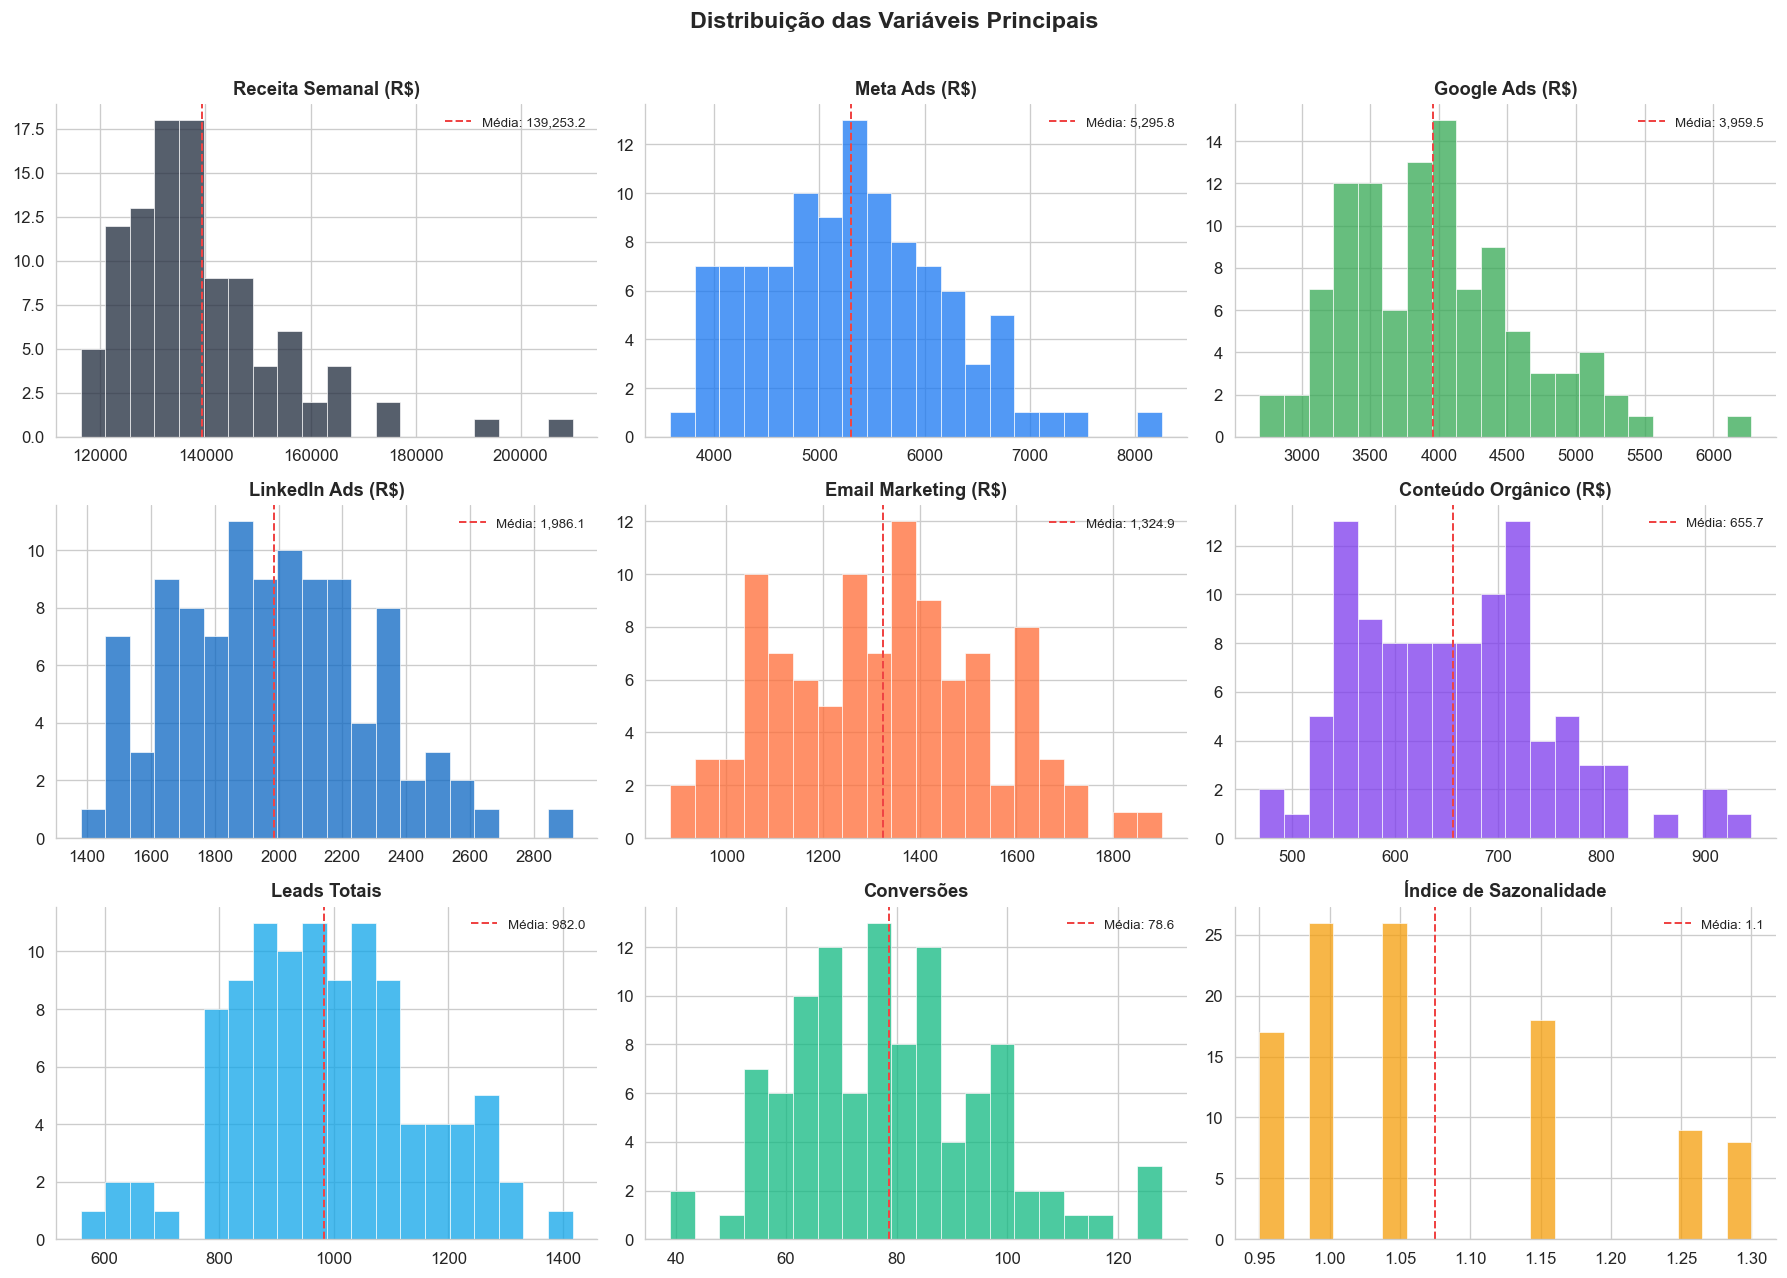

In [6]:
# Histogramas de todas as variáveis numéricas principais
variaveis_hist = {
    "revenue": ("Receita Semanal (R$)", "#1E293B"),
    "spend_meta_ads": ("Meta Ads (R$)", CORES["Meta Ads"]),
    "spend_google_ads": ("Google Ads (R$)", CORES["Google Ads"]),
    "spend_linkedin_ads": ("LinkedIn Ads (R$)", CORES["LinkedIn Ads"]),
    "spend_email_marketing": ("Email Marketing (R$)", CORES["Email Marketing"]),
    "spend_content_organic": ("Conteúdo Orgânico (R$)", CORES["Conteúdo Orgânico"]),
    "leads_total": ("Leads Totais", "#0EA5E9"),
    "conversions": ("Conversões", "#10B981"),
    "seasonality_index": ("Índice de Sazonalidade", "#F59E0B"),
}

n_vars = len(variaveis_hist)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3.5))
axes = axes.flatten()

for i, (col, (titulo, cor)) in enumerate(variaveis_hist.items()):
    ax = axes[i]
    ax.hist(df[col], bins=20, color=cor, alpha=0.75, edgecolor="white", linewidth=0.5)
    ax.axvline(df[col].mean(), color="#EF4444", linestyle="--", linewidth=1.2,
               label=f"Média: {df[col].mean():,.1f}")
    ax.set_title(titulo, fontsize=11, fontweight="bold")
    ax.legend(fontsize=8, frameon=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# Ocultar subplots vazios
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Distribuição das Variáveis Principais", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## Conclusão — O que Aprendemos e Próximos Passos

### Principais achados desta análise exploratória:

1. **Dados limpos e completos**: 104 semanas, sem valores nulos, todas as variáveis com distribuições razoáveis e sem outliers extremos.

2. **Sazonalidade forte**: a receita acompanha o calendário comercial brasileiro (picos em Black Friday, Natal, Dia dos Namorados), o que justifica incluir variáveis de sazonalidade no modelo.

3. **Alocação concentrada**: Meta Ads e Google Ads consomem ~70% do budget. A EDA sozinha não responde se essa concentração é ótima — o modelo de MMM e o otimizador de budget vão responder essa pergunta.

4. **Correlação moderada entre spend e receita**: isso é esperado em MMM. A relação real é não-linear (adstock + saturação), então correlação de Pearson subestima o vínculo. As transformações no próximo notebook vão capturar isso.

5. **Multicolinearidade entre canais**: os canais sobem e descem juntos porque o budget total varia junto. Monitoraremos o VIF na modelagem.

### Próximos passos:
- **Notebook 02**: Aplicar transformações de adstock e saturação de Hill nos canais de mídia.
- **Notebook 03**: Treinar o modelo de regressão (MMM) e decompor a receita por canal.
- **Notebook 04**: Otimizar a alocação de budget com base nos coeficientes do modelo.